> **Cell 1 — Setup & Imports**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
np.random.seed(42)
 
df = sns.load_dataset('titanic')
 
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (891, 15)


> **CELL 2 — Q1(a): First 8 and Last 5 Rows**

In [3]:
print("=" * 60)
print("FIRST 8 ROWS")
print("=" * 60)
display(df.head(8))
 
print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(df.tail(5))

FIRST 8 ROWS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False



LAST 5 ROWS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


> **CELL 3 — Q1(b): Shape, dtypes, describe() for numeric & categorical**

In [4]:
print("Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
 
print("\n--- Statistical Summary: Numeric Columns ---")
display(df.describe())
 
print("\n--- Statistical Summary: Categorical Columns ---")
display(df.describe(include=['object', 'category', 'bool']))

Shape: (891, 15)

--- Data Types ---
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

--- Statistical Summary: Numeric Columns ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Statistical Summary: Categorical Columns ---


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


> **CELL 4 — Q1(c): Missing Values Analysis**

In [5]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100
 
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
 
# Logical reasons for missingness
reasons = {
    'age':         'Age was not always recorded, especially for lower-class passengers; some boarded under aliases.',
    'embarked':    'Only 2 rows missing; likely a data entry omission for these specific passengers.',
    'deck':        'Cabin/deck info was mostly not recorded for 3rd-class passengers; not required for their tickets.',
    'embark_town': 'Same 2 rows as embarked — the port name is derived from the embarked code.'
}
missing_df['Likely Reason'] = missing_df.index.map(reasons)
 
print("=" * 60)
print("COLUMNS WITH MISSING VALUES")
print("=" * 60)
display(missing_df)

COLUMNS WITH MISSING VALUES


,Missing Count,Missing %,Likely Reason
age,177,19.87,"Age was not always recorded, especially for lo..."
embarked,2,0.22,Only 2 rows missing; likely a data entry omiss...
deck,688,77.22,Cabin/deck info was mostly not recorded for 3r...
embark_town,2,0.22,Same 2 rows as embarked — the port name is der...


> **CELL 5 — Q1(d): Overall & Per-Class Survival Rate**

In [6]:
overall_survival = df['survived'].mean()
 
class_survival = df.groupby('pclass')['survived'].mean().reset_index()
class_survival.columns = ['Passenger Class', 'Survival Rate']
class_survival['Survival Rate'] = class_survival['Survival Rate'].round(4)
 
overall_row = pd.DataFrame({'Passenger Class': ['Overall'], 'Survival Rate': [round(overall_survival, 4)]})
survival_summary = pd.concat([overall_row, class_survival], ignore_index=True)
 
print("=" * 60)
print("SURVIVAL RATE SUMMARY")
print("=" * 60)
display(survival_summary)

SURVIVAL RATE SUMMARY


,Passenger Class,Survival Rate
0,Overall,0.3838
1,1,0.6296
2,2,0.4728
3,3,0.2424


> **CELL 6 — Q2(a): Impute Missing Age Values**

In [8]:
"""
STRATEGY: Group-based median imputation using sex + pclass.
WHY: Age varies significantly by passenger class and sex.
     For example, 1st-class male passengers tend to be older than
     3rd-class female passengers. Using group medians preserves
     this heterogeneity better than a single global median.
LIMITATION: It assumes within-group age distributions are similar
            to observed passengers, which may not hold for passengers
            whose age is missing for non-random reasons.
"""
 
# Show group medians before imputation
group_medians = df.groupby(['sex', 'pclass'])['age'].median()
print("Group Medians (sex + pclass):")
print(group_medians)
 
# Apply group-based median imputation
df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)
 
print(f"\nMissing 'age' values remaining: {df['age'].isnull().sum()}")

Group Medians (sex + pclass):
sex     pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: age, dtype: float64

Missing 'age' values remaining: 0


> **CELL 7 — Q2(b): Drop 'deck' Column**

In [9]:
"""
JUSTIFICATION FOR DROPPING 'deck':
The 'deck' column has ~77% missing values. Imputing a column with
this level of missingness would be highly speculative — any imputed
values would dominate the data and introduce significant bias.
Unlike 'age', there is no reliable proxy variable from which to
infer deck. Dropping it is the more honest analytical choice.
"""
 
df.drop(columns=['deck'], inplace=True)
print("'deck' column dropped.")
print(f"Remaining columns: {list(df.columns)}")

'deck' column dropped.
Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


> **CELL 8 — Q2(c): Handle Missing 'embarked' Using Mode**

In [10]:
mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)
 
# Also fix embark_town
mode_town = df['embark_town'].mode()[0]
df['embark_town'].fillna(mode_town, inplace=True)
 
print(f"Mode used for 'embarked': {mode_embarked}")
print(f"Null values in 'embarked': {df['embarked'].isnull().sum()}")
print(f"Null values in 'embark_town': {df['embark_town'].isnull().sum()}")

Mode used for 'embarked': S
Null values in 'embarked': 0
Null values in 'embark_town': 0


> **CELL 9 — Q2(d): Create 'family_size' and 'travel_group'**

In [11]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
 
def categorize_travel(size):
    if size == 1:
        return 'Solo'
    elif 2 <= size <= 4:
        return 'Small'
    else:
        return 'Large'
 
df['travel_group'] = df['family_size'].apply(categorize_travel)
 
print("Value counts for 'travel_group':")
print(df['travel_group'].value_counts())

Value counts for 'travel_group':
travel_group
Solo     537
Small    292
Large     62
Name: count, dtype: int64


> **CELL 10 — Q2(e): Create 'age_group' Column**

In [12]:
bins   = [0, 12, 17, 59, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']
 
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
 
# Verify no NaN bins
print(f"NaN in age_group: {df['age_group'].isnull().sum()}")
print("\nValue counts for 'age_group':")
print(df['age_group'].value_counts())

NaN in age_group: 0

Value counts for 'age_group':
age_group
Adult     752
Child      69
Teen       44
Senior     26
Name: count, dtype: int64


> **CELL 11 — Q2(f): Final Null-Check**

In [13]:
columns_in_use = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
                  'fare', 'embarked', 'class', 'who', 'embark_town',
                  'alone', 'family_size', 'travel_group', 'age_group']
 
null_check = df[columns_in_use].isnull().sum().reset_index()
null_check.columns = ['Column', 'Null Count']
 
print("=" * 40)
print("FINAL NULL-CHECK SUMMARY")
print("=" * 40)
display(null_check)
print(f"\nTotal nulls across used columns: {df[columns_in_use].isnull().sum().sum()}")

FINAL NULL-CHECK SUMMARY


,Column,Null Count
0,survived,0
1,pclass,0
2,sex,0
3,age,0
4,sibsp,0
5,parch,0
6,fare,0
7,embarked,0
8,class,0
9,who,0



Total nulls across used columns: 0


> **CELL 12 — Q3(a): Age Histogram — 3 Bin Sizes Side-by-Side**

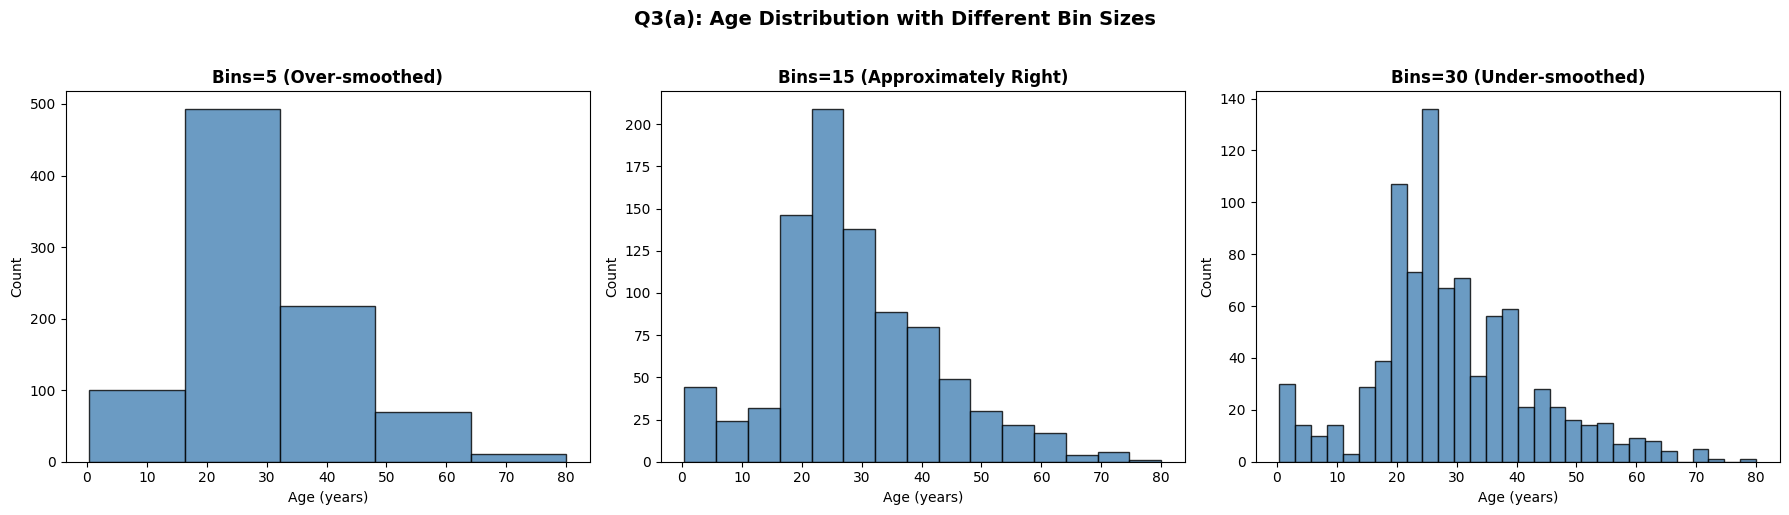

'\nINTERPRETATION:\n- Bins=5  → Too few bars, hides natural variation and peaks. Over-smoothed.\n- Bins=15 → Reveals the overall shape clearly — a right-skewed distribution\n             with peaks in young adults (~20-30) and a smaller bump in children.\n             This is the best choice.\n- Bins=30 → Too many bars, creates a jagged and noisy appearance that makes it\n             hard to see the underlying shape. Under-smoothed.\nBEST BIN SIZE: 15 — it balances granularity and clarity.\n'

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
bin_sizes = [5, 15, 30]
titles = [
    'Bins=5 (Over-smoothed)',
    'Bins=15 (Approximately Right)',
    'Bins=30 (Under-smoothed)'
]
 
for ax, bins_val, title in zip(axes, bin_sizes, titles):
    ax.hist(df['age'], bins=bins_val, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
 
plt.suptitle('Q3(a): Age Distribution with Different Bin Sizes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

"""
INTERPRETATION:
- Bins=5  → Too few bars, hides natural variation and peaks. Over-smoothed.
- Bins=15 → Reveals the overall shape clearly — a right-skewed distribution
             with peaks in young adults (~20-30) and a smaller bump in children.
             This is the best choice.
- Bins=30 → Too many bars, creates a jagged and noisy appearance that makes it
             hard to see the underlying shape. Under-smoothed.
BEST BIN SIZE: 15 — it balances granularity and clarity.
"""

> **CELL 13 — Q3(b): Best-Bin Histogram with KDE Overlay**

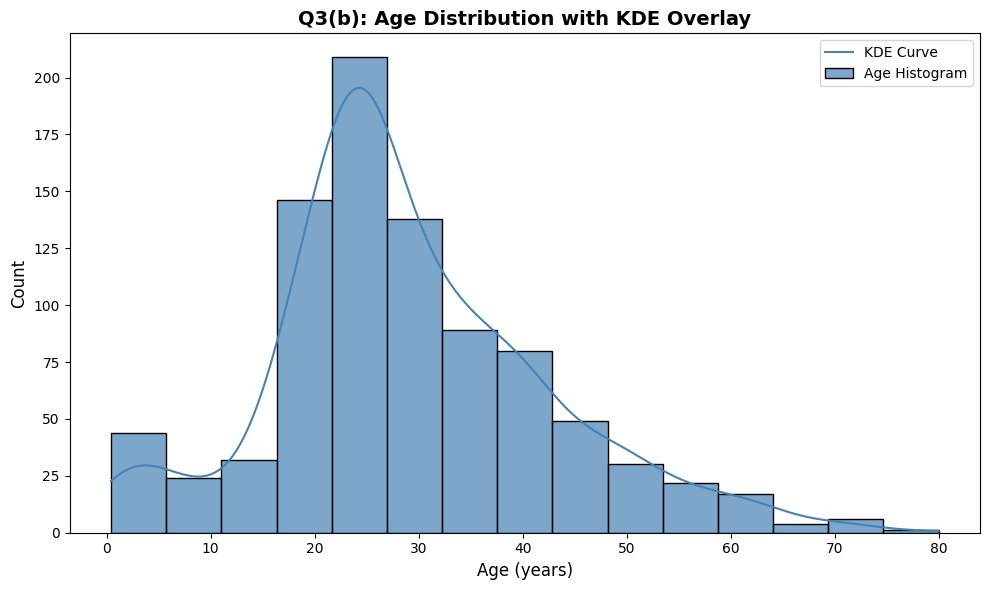

'\nINTERPRETATION:\nThe distribution is right-skewed with the bulk of passengers concentrated\nbetween ages 20 and 40. There is a noticeable secondary peak around ages 0-5,\nindicating a significant number of young children aboard, likely families.\nThe long right tail represents older passengers, but they were relatively rare.\nThis bimodal tendency (young adults + young children) reflects the social\ncomposition of a 1912 transatlantic voyage — primarily working-age emigrants\nand some families with young children in 3rd class.\n'

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.histplot(df['age'], bins=15, kde=True, color='steelblue',
             edgecolor='black', alpha=0.7, ax=ax)
 
ax.set_title('Q3(b): Age Distribution with KDE Overlay', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(['KDE Curve', 'Age Histogram'], loc='upper right')
 
plt.tight_layout()
plt.show()


"""
INTERPRETATION:
The distribution is right-skewed with the bulk of passengers concentrated
between ages 20 and 40. There is a noticeable secondary peak around ages 0-5,
indicating a significant number of young children aboard, likely families.
The long right tail represents older passengers, but they were relatively rare.
This bimodal tendency (young adults + young children) reflects the social
composition of a 1912 transatlantic voyage — primarily working-age emigrants
and some families with young children in 3rd class.
"""

> **CELL 14 — Q3(c): KDE — Survivors vs Non-Survivors**

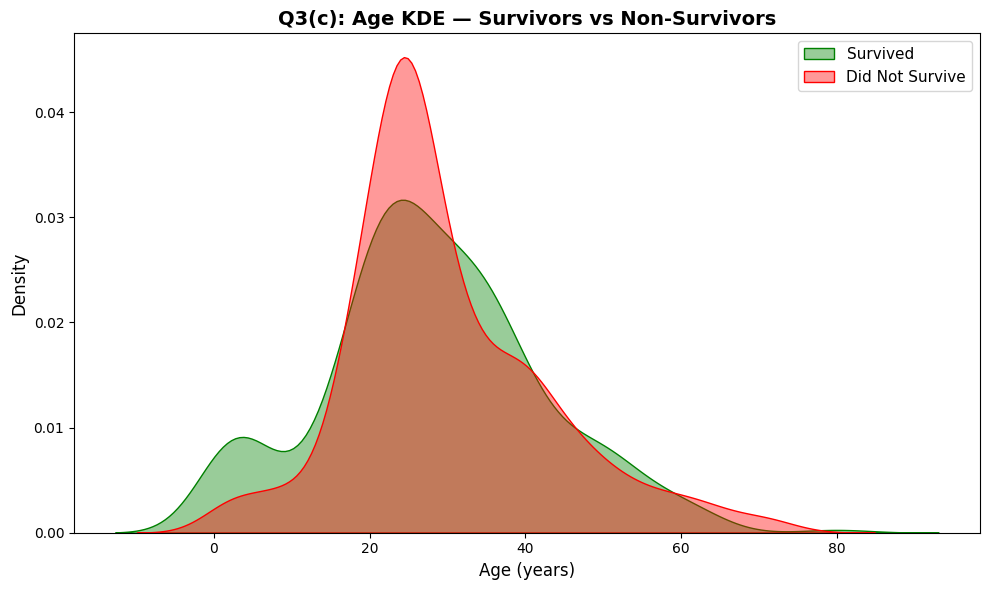

'\nINTERPRETATION:\n- Ages 0–10 (Children): The survivor KDE is notably higher than non-survivor KDE,\n  suggesting children were prioritised during evacuation ("women and children first").\n- Ages 18–35 (Young Adults): Non-survivors dominate this range — many were male\n  passengers who were not given priority for lifeboats.\n- The distributions begin to converge at older ages (60+), suggesting elderly\n  passengers had mixed survival outcomes regardless of the rescue priority.\n'

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.kdeplot(df[df['survived'] == 1]['age'], ax=ax, label='Survived', color='green', fill=True, alpha=0.4)
sns.kdeplot(df[df['survived'] == 0]['age'], ax=ax, label='Did Not Survive', color='red', fill=True, alpha=0.4)
 
ax.set_title('Q3(c): Age KDE — Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- Ages 0–10 (Children): The survivor KDE is notably higher than non-survivor KDE,
  suggesting children were prioritised during evacuation ("women and children first").
- Ages 18–35 (Young Adults): Non-survivors dominate this range — many were male
  passengers who were not given priority for lifeboats.
- The distributions begin to converge at older ages (60+), suggesting elderly
  passengers had mixed survival outcomes regardless of the rescue priority.
"""

> **CELL 15 — Q4(a): Fare Distribution — Raw & Log-Transforme**

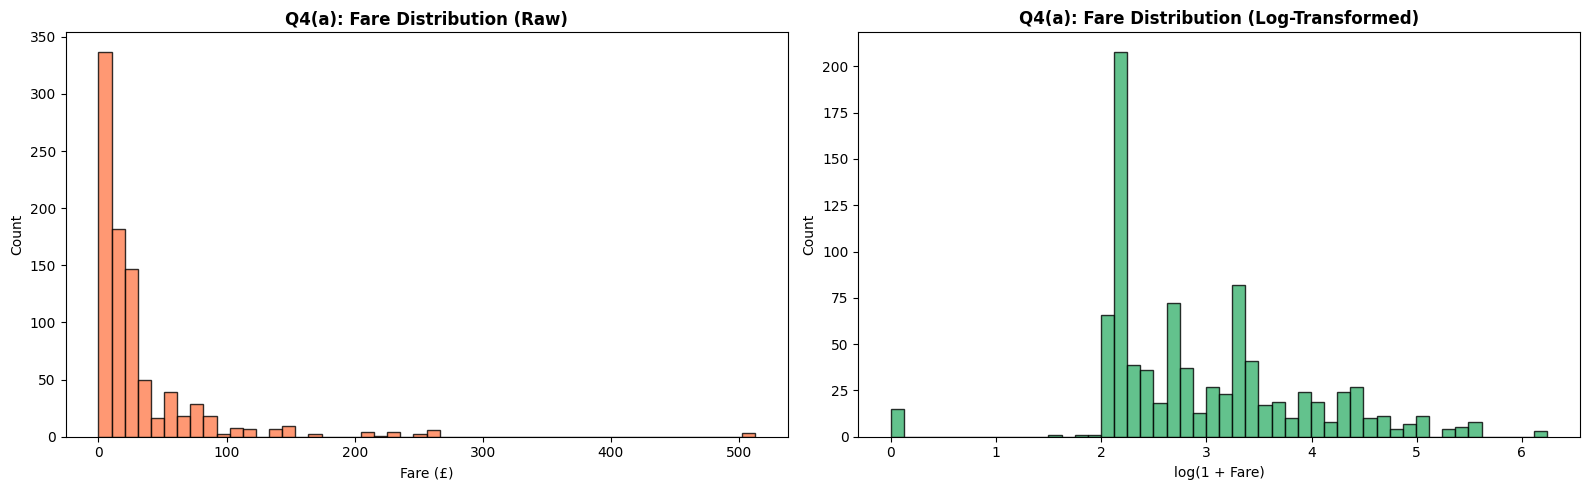

'\nINTERPRETATION:\n- Raw: Extremely right-skewed. Most passengers paid low fares but a few paid\n  very high fares (>£300), compressing the bulk of data near zero and making\n  the plot nearly unreadable.\n- Log-transformed: The distribution becomes approximately bell-shaped and\n  symmetric, revealing three natural clusters that correspond to the three\n  ticket classes. This transformed version is far more informative for analysis.\n'

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Raw
axes[0].hist(df['fare'], bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[0].set_title('Q4(a): Fare Distribution (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Count')
 
# Log-transformed
df['fare_log'] = np.log1p(df['fare'])
axes[1].hist(df['fare_log'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Q4(a): Fare Distribution (Log-Transformed)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- Raw: Extremely right-skewed. Most passengers paid low fares but a few paid
  very high fares (>£300), compressing the bulk of data near zero and making
  the plot nearly unreadable.
- Log-transformed: The distribution becomes approximately bell-shaped and
  symmetric, revealing three natural clusters that correspond to the three
  ticket classes. This transformed version is far more informative for analysis.
"""

> **CELL 16 — Q4(b): Extreme Fare Outliers (>300)**

In [23]:
outliers = df[df['fare'] > 300]
print(f"Number of extreme fare outliers (fare > 300): {len(outliers)}")
print("\nOutlier Passenger Details:")
display(outliers[['pclass', 'sex', 'age', 'fare', 'survived', 'embarked']])
 
"""
INTERPRETATION:
These are legitimate values, not errors. Passengers paying fares above £300
were exclusively 1st-class passengers who purchased deluxe suites or cabins
aboard the Titanic. In 1912, £300 was a small fortune — equivalent to tens of
thousands in today's money. These were among the wealthiest individuals on
board, and their fares reflected the luxury accommodation they received.
"""

Number of extreme fare outliers (fare > 300): 3

Outlier Passenger Details:


,pclass,sex,age,fare,survived,embarked
258,1,female,35.0,512.3292,1,C
679,1,male,36.0,512.3292,1,C
737,1,male,35.0,512.3292,1,C


"\nINTERPRETATION:\nThese are legitimate values, not errors. Passengers paying fares above £300\nwere exclusively 1st-class passengers who purchased deluxe suites or cabins\naboard the Titanic. In 1912, £300 was a small fortune — equivalent to tens of\nthousands in today's money. These were among the wealthiest individuals on\nboard, and their fares reflected the luxury accommodation they received.\n"

> **CELL 17 — Q4(c): Box Plot — Fare by Passenger Class**

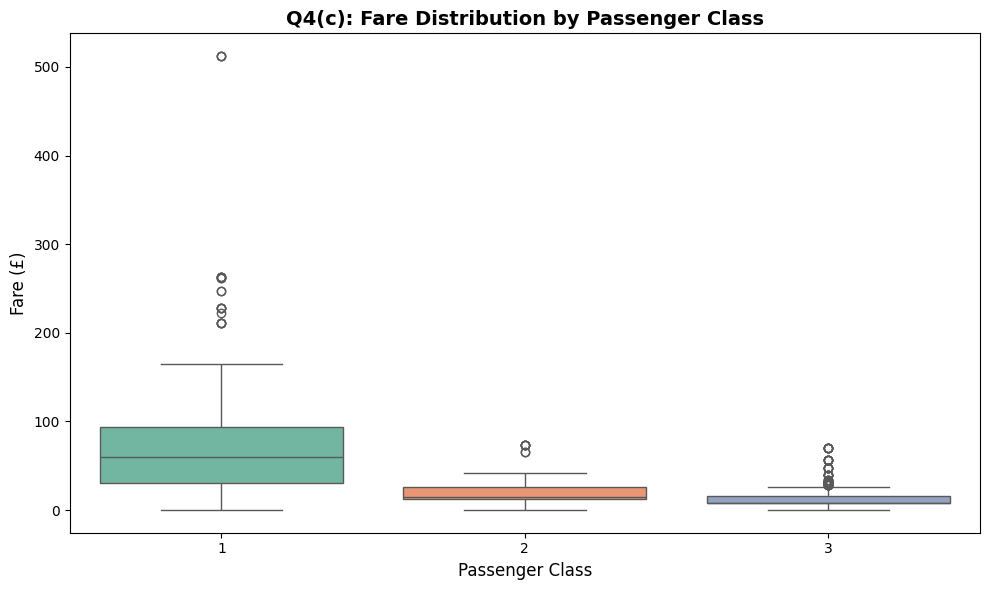

'\nINTERPRETATION:\n- 1st Class has the greatest internal spread and the most extreme outliers,\n  reflecting a highly variable pricing structure — some passengers paid a basic\n  1st-class fare while others paid for luxury suites, creating enormous variance.\n- 2nd Class shows moderate, tightly clustered fares with few outliers, suggesting\n  more standardised mid-tier pricing.\n- 3rd Class has the lowest fares overall and very little spread, indicating a\n  fixed economy fare structure with minimal variation.\n'

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2', ax=ax)
 
ax.set_title('Q4(c): Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- 1st Class has the greatest internal spread and the most extreme outliers,
  reflecting a highly variable pricing structure — some passengers paid a basic
  1st-class fare while others paid for luxury suites, creating enormous variance.
- 2nd Class shows moderate, tightly clustered fares with few outliers, suggesting
  more standardised mid-tier pricing.
- 3rd Class has the lowest fares overall and very little spread, indicating a
  fixed economy fare structure with minimal variation.
"""

> **CELL 18 — Q5(a): Count Plots — pclass, sex, embarked**

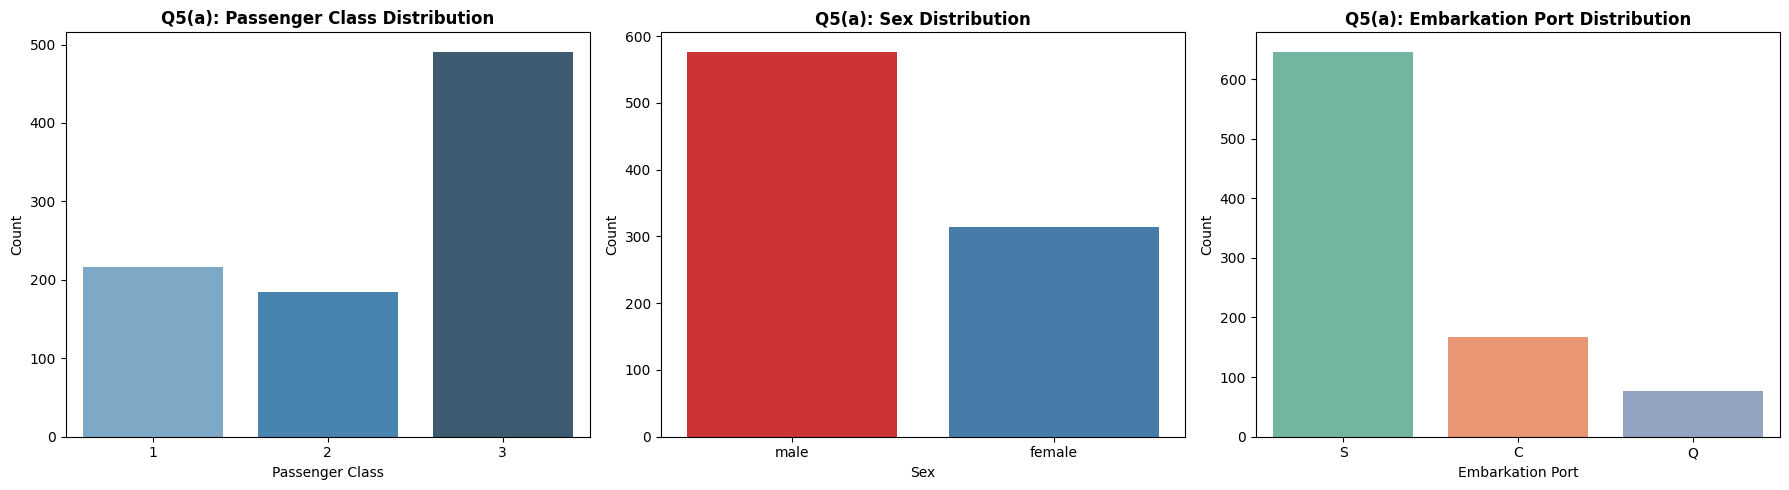

"\nINTERPRETATIONS:\n- pclass: 3rd class dominates (~55%), showing the Titanic carried more\n  economy passengers than any other group.\n- sex: Male passengers significantly outnumber female passengers (~65% male),\n  reflecting the emigrant demographic of the era.\n- embarked: Southampton (S) is overwhelmingly the most common boarding port,\n  as it was the Titanic's primary departure point.\n"

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
sns.countplot(data=df, x='pclass', palette='Blues_d', ax=axes[0])
axes[0].set_title('Q5(a): Passenger Class Distribution', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
 
sns.countplot(data=df, x='sex', palette='Set1', ax=axes[1])
axes[1].set_title('Q5(a): Sex Distribution', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
 
sns.countplot(data=df, x='embarked', palette='Set2', ax=axes[2])
axes[2].set_title('Q5(a): Embarkation Port Distribution', fontweight='bold')
axes[2].set_xlabel('Embarkation Port')
axes[2].set_ylabel('Count')
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATIONS:
- pclass: 3rd class dominates (~55%), showing the Titanic carried more
  economy passengers than any other group.
- sex: Male passengers significantly outnumber female passengers (~65% male),
  reflecting the emigrant demographic of the era.
- embarked: Southampton (S) is overwhelmingly the most common boarding port,
  as it was the Titanic's primary departure point.
"""